In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import os
import numpy

In [2]:
data_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

trainset = datasets.ImageFolder('faces', data_transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=5, shuffle=True, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [3]:
def imshow(inputs, picname):
    plt.ion()
    inputs = inputs / 2 + 0.5
    inputs = inputs.numpy().transpose((1, 2, 0))
    plt.imshow(inputs)
    plt.pause(0.01)
    plt.savefig(picname + ".jpg")
    plt.close()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


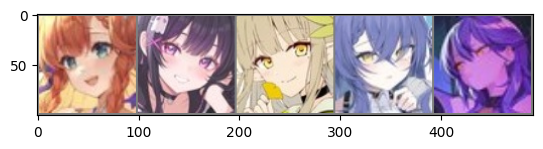

In [4]:
inputs, _ = next(iter(trainloader))
imshow(torchvision.utils.make_grid(inputs), "RealDataSample")

In [5]:
class D(nn.Module):
    def __init__(self, nc, ndf):
        super(D, self).__init__()
        self.layer1 = nn.Sequential(nn.Conv2d(nc, ndf, kernel_size=4, stride=2, padding=1),
                                    nn.BatchNorm2d(ndf), nn.LeakyReLU(0.2, inplace=True))
        
        self.layer2 = nn.Sequential(nn.Conv2d(ndf, ndf*2, kernel_size=4, stride=2, padding=1),
                                    nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, inplace=True))
        
        self.layer3 = nn.Sequential(nn.Conv2d(ndf*2, ndf*4, kernel_size=4, stride=2, padding=1),
                                    nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, inplace=True))
        
        self.layer4 = nn.Sequential(nn.Conv2d(ndf*4, ndf*8, kernel_size=4, stride=2, padding=1),
                                    nn.BatchNorm2d(ndf*8), nn.LeakyReLU(0.2, inplace=True))
        
        self.fc = nn.Sequential(nn.Linear(256*6*6, 1), nn.Sigmoid())

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = out.view(-1, 256*6*6)
        out = self.fc(out)
        return out

In [6]:
class G(nn.Module):
    def __init__(self, nc, ngf, nz, feature_size):
        super(G, self).__init__()
        self.prj = nn.Linear(feature_size, nz*6*6)
        self.layer1 = nn.Sequential(nn.ConvTranspose2d(nz, ngf*4, kernel_size=4, stride=2, padding=1),
                                    nn.BatchNorm2d(ngf*4), nn.ReLU())
        
        self.layer2 = nn.Sequential(nn.ConvTranspose2d(ngf*4, ngf*2, kernel_size=4, stride=2, padding=1),
                                    nn.BatchNorm2d(ngf*2), nn.ReLU())
        
        self.layer3 = nn.Sequential(nn.ConvTranspose2d(ngf*2, ngf, kernel_size=4, stride=2, padding=1),
                                    nn.BatchNorm2d(ngf), nn.ReLU())
        
        self.layer4 = nn.Sequential(nn.ConvTranspose2d(ngf, nc, kernel_size=4, stride=2, padding=1),
                                    nn.Tanh())
        
    def forward(self, x):
        out = self.prj(x)
        out = out.view(-1, 1024, 6, 6)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        return out

In [7]:
d = D(3, 32)
g = G(3, 128, 1024, 100)

In [8]:
criterion = nn.BCELoss()
d_optimizer = torch.optim.Adam(d.parameters(), lr=0.0003)
g_optimizer = torch.optim.Adam(g.parameters(), lr=0.0003)

In [9]:
def train(d, g, criterion, d_optimizer, g_optimizer, epochs=1, show_every=1000, print_every=10):
    iter_count = 0
    for epoch in range(epochs):
        for inputs, _ in trainloader:
            real_inputs = inputs
            fake_inputs = g(torch.randn(5, 100))

            real_labels = torch.ones(real_inputs.size(0), 1)
            fake_labels = torch.zeros(5, 1)

            real_outputs = d(real_inputs)
            d_loss_real = criterion(real_outputs, real_labels)
            real_scores = real_outputs

            fake_outputs = d(fake_inputs)
            d_loss_fake = criterion(fake_outputs, fake_labels)
            fake_scores = fake_outputs

            d_loss = d_loss_real + d_loss_fake
            d_optimizer.zero_grad()
            d_loss.backward()
            d_optimizer.step()

            fake_inputs = g(torch.randn(5, 100))
            outputs = d(fake_inputs)
            real_labels = torch.ones(outputs.size(0), 1)
            g_loss = criterion(outputs, real_labels)

            g_optimizer.zero_grad()
            g_loss.backward()
            g_optimizer.step()

            if(iter_count % show_every == 0):
                print('Epoch: {}, Iter: {}, D: {:.4}, G: {:.4}'.format(epoch, iter_count, d_loss.item(), g_loss.item()))

                picname = "Epoch_" + str(epoch) + "Iter_" + str(iter_count)
                imshow(torchvision.utils.make_grid(fake_inputs.data), picname)

            if(iter_count % print_every == 0):
                print('Epoch: {}, Iter: {}, D: {:.4}, G:{:.4}'.format(epoch, iter_count, d_loss.item(), g_loss.item()))

            iter_count += 1

    print("Finished Training")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch: 0, Iter: 0, D: 1.658, G: 0.741


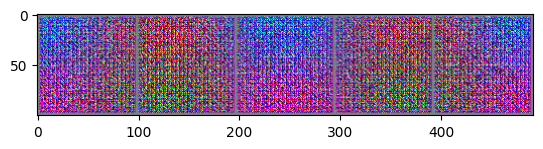

Epoch: 0, Iter: 0, D: 1.658, G:0.741
Epoch: 0, Iter: 10, D: 0.8467, G:2.174
Epoch: 0, Iter: 20, D: 0.379, G:6.064
Epoch: 0, Iter: 30, D: 0.1, G:6.199


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch: 1, Iter: 40, D: 0.1626, G:6.453
Epoch: 1, Iter: 50, D: 0.08016, G:8.555
Epoch: 1, Iter: 60, D: 0.1108, G:7.725
Epoch: 2, Iter: 70, D: 0.006053, G:11.36
Epoch: 2, Iter: 80, D: 0.01526, G:12.0
Epoch: 2, Iter: 90, D: 0.02014, G:9.104
Epoch: 2, Iter: 100, D: 0.06918, G:8.637
Epoch: 3, Iter: 110, D: 0.006134, G:11.52
Epoch: 3, Iter: 120, D: 0.1024, G:9.342
Epoch: 3, Iter: 130, D: 0.03013, G:10.2
Epoch: 4, Iter: 140, D: 0.02482, G:6.484
Epoch: 4, Iter: 150, D: 0.03346, G:6.673
Epoch: 4, Iter: 160, D: 0.06718, G:8.118
Epoch: 4, Iter: 170, D: 0.001591, G:12.32
Epoch: 5, Iter: 180, D: 0.02197, G:9.467
Epoch: 5, Iter: 190, D: 0.01206, G:17.84
Epoch: 5, Iter: 200, D: 0.02577, G:5.232
Epoch: 6, Iter: 210, D: 0.007486, G:6.976
Epoch: 6, Iter: 220, D: 0.004889, G:21.08
Epoch: 6, Iter: 230, D: 0.003551, G:18.69
Epoch: 6, Iter: 240, D: 0.0003133, G:14.53
Epoch: 7, Iter: 250, D: 0.02312, G:7.018
Epoch: 7, Iter: 260, D: 0.004391, G:7.521
Epoch: 7, Iter: 270, D: 0.002777, G:8.839
Epoch: 8, Iter: 2

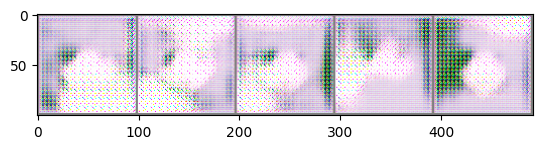

Epoch: 28, Iter: 1000, D: 0.008353, G:7.888
Epoch: 28, Iter: 1010, D: 0.01326, G:7.142


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch: 29, Iter: 1020, D: 0.2304, G:9.052
Epoch: 29, Iter: 1030, D: 0.01166, G:10.9
Epoch: 29, Iter: 1040, D: 0.2385, G:10.64
Epoch: 30, Iter: 1050, D: 0.007667, G:8.563
Epoch: 30, Iter: 1060, D: 0.01578, G:5.447
Epoch: 30, Iter: 1070, D: 0.00267, G:9.009
Epoch: 30, Iter: 1080, D: 0.01045, G:2.805
Epoch: 31, Iter: 1090, D: 0.0484, G:10.11
Epoch: 31, Iter: 1100, D: 0.002967, G:9.17
Epoch: 31, Iter: 1110, D: 0.01323, G:15.17
Epoch: 32, Iter: 1120, D: 0.08752, G:13.01
Epoch: 32, Iter: 1130, D: 0.001005, G:6.506
Epoch: 32, Iter: 1140, D: 0.08036, G:5.949
Epoch: 32, Iter: 1150, D: 0.6264, G:8.497
Epoch: 33, Iter: 1160, D: 0.7115, G:10.76
Epoch: 33, Iter: 1170, D: 0.306, G:9.42
Epoch: 33, Iter: 1180, D: 0.3195, G:3.912
Epoch: 34, Iter: 1190, D: 0.07208, G:6.751
Epoch: 34, Iter: 1200, D: 0.1868, G:8.723
Epoch: 34, Iter: 1210, D: 0.02952, G:10.85
Epoch: 34, Iter: 1220, D: 0.008312, G:8.398
Epoch: 35, Iter: 1230, D: 0.2169, G:7.814
Epoch: 35, Iter: 1240, D: 0.7308, G:3.448
Epoch: 35, Iter: 1250

: 

In [10]:
train(d, g, criterion, d_optimizer, g_optimizer, epochs=300)